In [ ]:
import kagglehub

path = kagglehub.dataset_download("mahdieizadpanah/birjand-university-mobile-palmprint-databasebmpd")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/mahdieizadpanah/birjand-university-mobile-palmprint-databasebmpd/versions/1


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

try:
    print(f'Menggunakan path: {path}')
    for root, dirs, files in os.walk(path):
        if files:
            print(f'Direktori ditemukan: {root}')
            print(f'Contoh file: {files[:5]}')
            break
except NameError:
    print("Error: Variabel 'path' belum didefinisikan. Silakan jalankan sel pertama (download dataset) terlebih dahulu.")

Menggunakan path: /root/.cache/kagglehub/datasets/mahdieizadpanah/birjand-university-mobile-palmprint-databasebmpd/versions/1
Direktori ditemukan: /root/.cache/kagglehub/datasets/mahdieizadpanah/birjand-university-mobile-palmprint-databasebmpd/versions/1/Birjand University Mobile Palmprint Database (BMPD)/014
Contoh file: ['014_S_L_24.JPG', '014_S_R_14.JPG', '014_S_L_23.JPG', '014_F_R_5.JPG', '014_F_R_4.JPG']


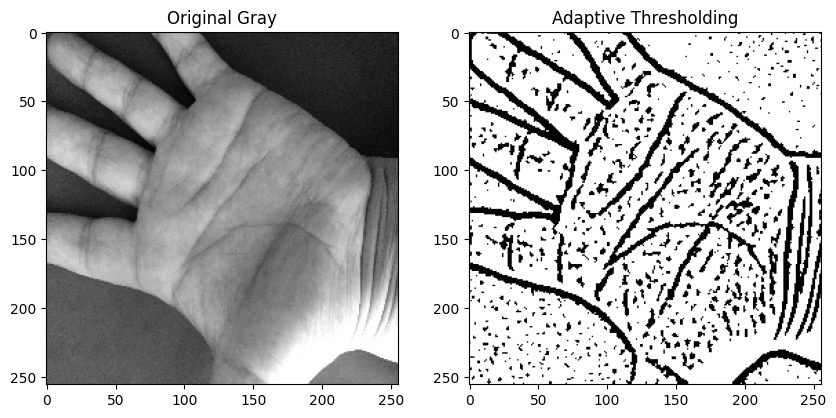

In [ ]:
def preprocess_palmprint(image_path):
    # Load image dalam grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Resize untuk standarisasi (opsional, misal 256x256)
    img = cv2.resize(img, (256, 256))

    # Melakukan Gaussian Blur untuk mengurangi noise sebelum thresholding
    blurred = cv2.GaussianBlur(img, (5, 5), 0)

    # Adaptive Thresholding
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    return img, thresh

example_img_path = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(('.bmp', '.jpg', '.png')):
            example_img_path = os.path.join(root, f)
            break
    if example_img_path: break

if example_img_path:
    original, processed = preprocess_palmprint(example_img_path)

    # Visualisasi hasil
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Original Gray')
    plt.imshow(original, cmap='gray')

    plt.subplot(1, 2, 2)
    plt.title('Adaptive Thresholding')
    plt.imshow(processed, cmap='gray')
    plt.show()
else:
    print('Tidak ditemukan file gambar dalam dataset.')

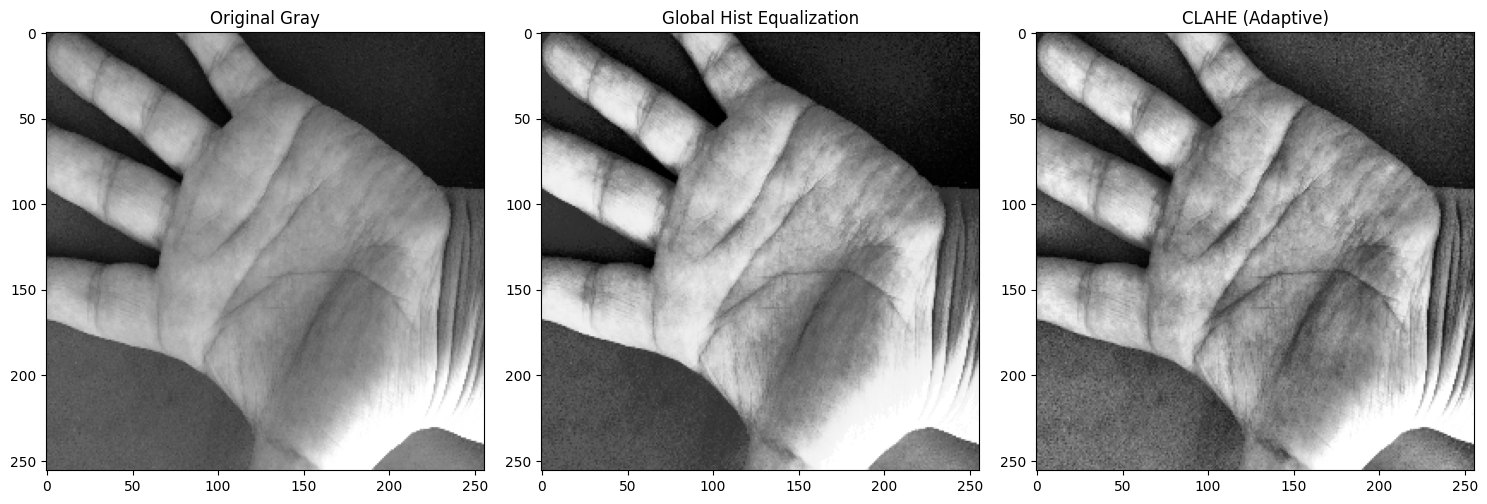

/tmp/ipykernel_411/3766927734.py:42: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(original.ravel(), 256, [0, 256])
/tmp/ipykernel_411/3766927734.py:46: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(global_eq.ravel(), 256, [0, 256])
/tmp/ipykernel_411/3766927734.py:50: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(clahe_eq.ravel(), 256, [0, 256])


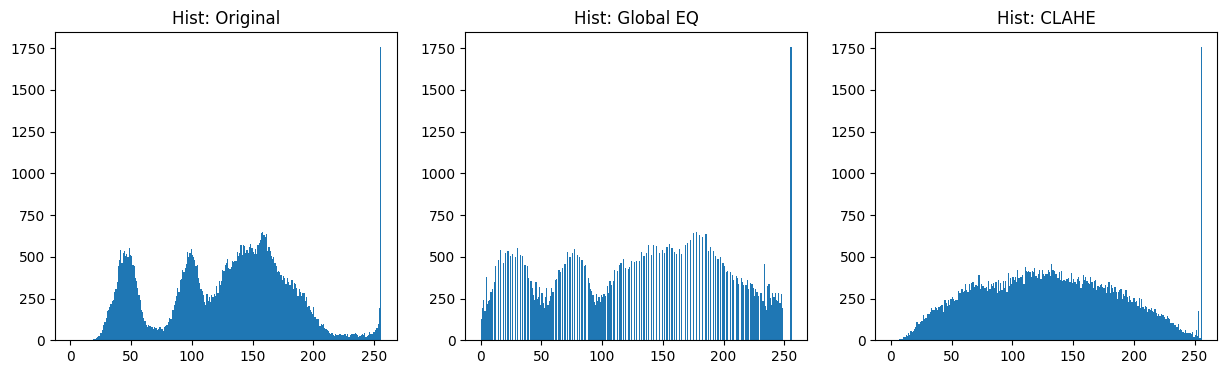

In [ ]:
def apply_histogram_equalization(image_path):
    # Load image dalam grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    img = cv2.resize(img, (256, 256))

    # 1. Global Histogram Equalization
    equ = cv2.equalizeHist(img)

    # 2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl1 = clahe.apply(img)

    return img, equ, cl1

if example_img_path:
    original, global_eq, clahe_eq = apply_histogram_equalization(example_img_path)

    # Visualisasi perbandingan
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title('Original Gray')
    plt.imshow(original, cmap='gray')

    plt.subplot(1, 3, 2)
    plt.title('Global Hist Equalization')
    plt.imshow(global_eq, cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title('CLAHE (Adaptive)')
    plt.imshow(clahe_eq, cmap='gray')

    plt.tight_layout()
    plt.show()

    # Plot Histogram untuk melihat distribusi intensitas
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.hist(original.ravel(), 256, [0, 256])
    plt.title('Hist: Original')

    plt.subplot(1, 3, 2)
    plt.hist(global_eq.ravel(), 256, [0, 256])
    plt.title('Hist: Global EQ')

    plt.subplot(1, 3, 3)
    plt.hist(clahe_eq.ravel(), 256, [0, 256])
    plt.title('Hist: CLAHE')
    plt.show()
else:
    print('Contoh gambar tidak ditemukan.')

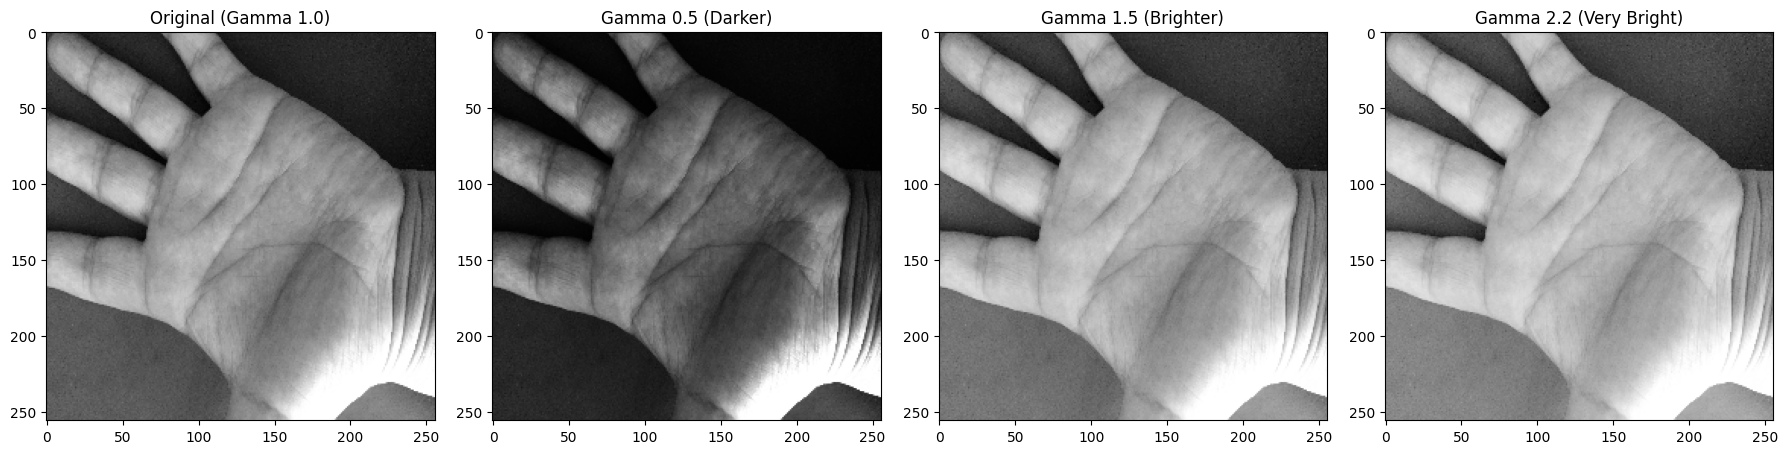

In [ ]:
def apply_gamma_correction(image_path, gamma=1.0):
    # Load image dalam grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    img = cv2.resize(img, (256, 256))

    # Membangun lookup table untuk gamma correction
    # Rumus: s = c * r^gamma
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")

    # Mengaplikasikan transformasi menggunakan lookup table (lebih cepat)
    return cv2.LUT(img, table)

if example_img_path:
    # Mencoba beberapa nilai gamma
    gamma_05 = apply_gamma_correction(example_img_path, gamma=0.5) # Lebih gelap
    gamma_15 = apply_gamma_correction(example_img_path, gamma=1.5) # Lebih terang
    gamma_22 = apply_gamma_correction(example_img_path, gamma=2.2) # Sangat terang

    # Visualisasi perbandingan
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.title('Original (Gamma 1.0)')
    plt.imshow(cv2.resize(cv2.imread(example_img_path, 0), (256,256)), cmap='gray')

    plt.subplot(1, 4, 2)
    plt.title('Gamma 0.5 (Darker)')
    plt.imshow(gamma_05, cmap='gray')

    plt.subplot(1, 4, 3)
    plt.title('Gamma 1.5 (Brighter)')
    plt.imshow(gamma_15, cmap='gray')

    plt.subplot(1, 4, 4)
    plt.title('Gamma 2.2 (Very Bright)')
    plt.imshow(gamma_22, cmap='gray')

    plt.tight_layout()
    plt.show()
else:
    print('Contoh gambar tidak ditemukan.')

Total gambar yang tersedia: 1612
Gambar terpilih (Index 10): 014_F_R_2.JPG


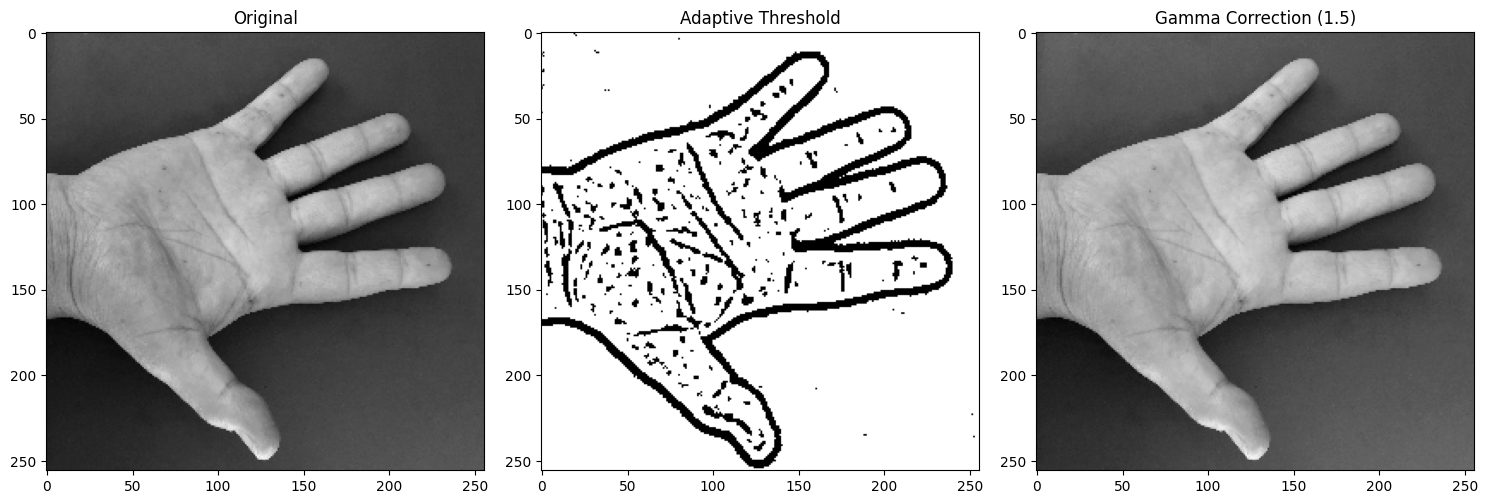

In [ ]:
import os

# Collecting all pictures path into a list
all_images = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(('.bmp', '.jpg', '.png')):
            all_images.append(os.path.join(root, f))

print(f"Total gambar yang tersedia: {len(all_images)}")

# Memasukkan index foto
pilih_index = 10

if 0 <= pilih_index < len(all_images):
    selected_path = all_images[pilih_index]
    print(f"Gambar terpilih (Index {pilih_index}): {os.path.basename(selected_path)}")

    # Running Adaptive Thresholding
    orig, thresh = preprocess_palmprint(selected_path)

    # Running Gamma Correction
    gamma_res = apply_gamma_correction(selected_path, gamma=1.5)

    # Visualisasi
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title('Original')
    plt.imshow(orig, cmap='gray')

    plt.subplot(1, 3, 2)
    plt.title('Adaptive Threshold')
    plt.imshow(thresh, cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title('Gamma Correction (1.5)')
    plt.imshow(gamma_res, cmap='gray')

    plt.tight_layout()
    plt.show()
else:
    print(f"Index {pilih_index} di luar jangkauan! Pilih antara 0 sampai {len(all_images)-1}")

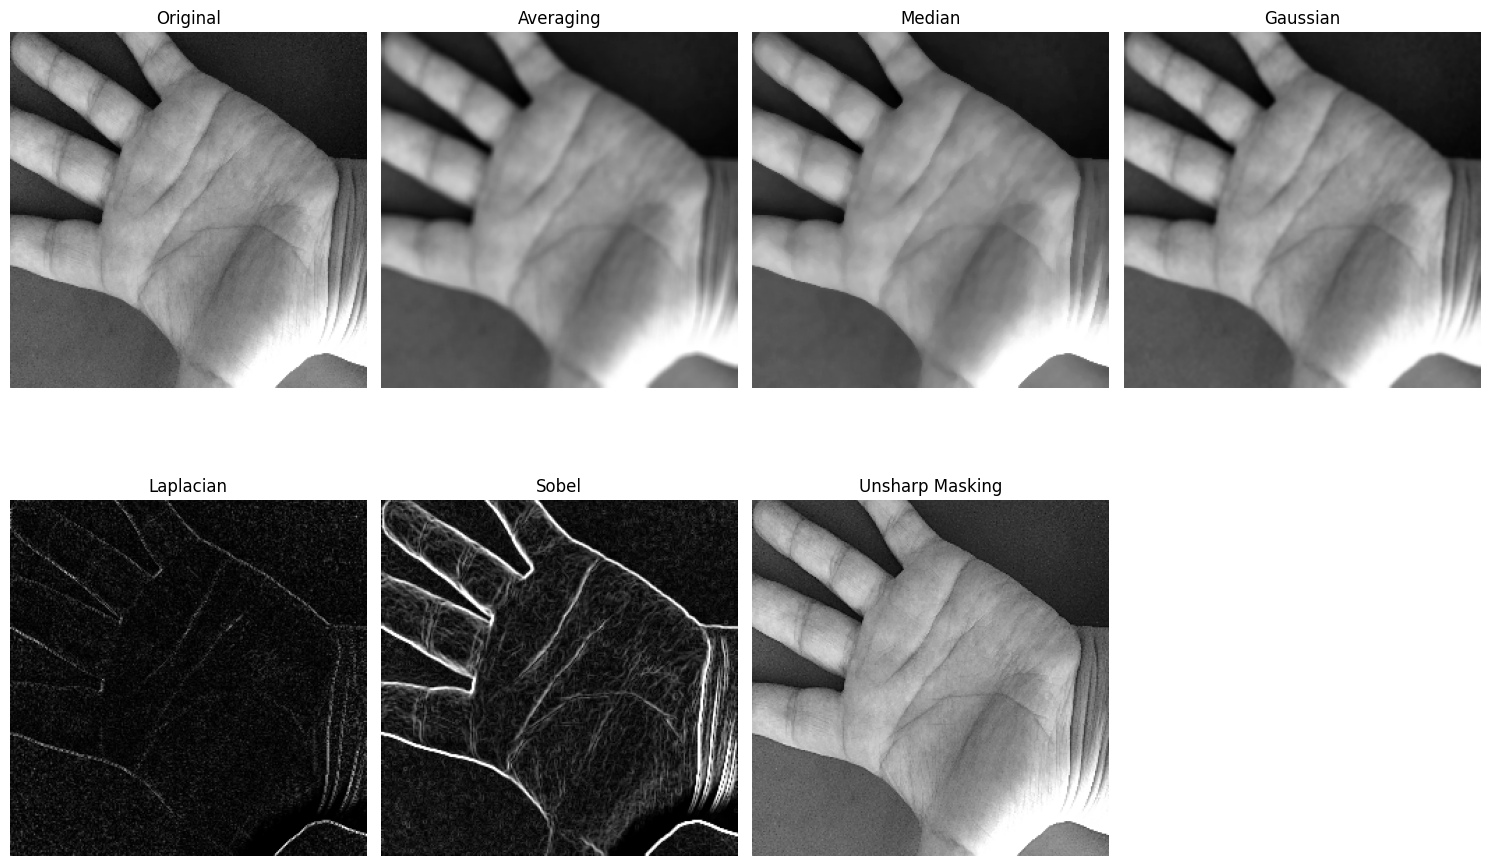

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_spatial_filtering(img):
    # --- 1. SMOOTHING FILTERS (Low-pass Filters) ---

    # Averaging Filter (Mean Filter) - Menggunakan kernel 5x5
    blur_avg = cv2.blur(img, (5, 5))

    # Median Filter - Sangat efektif untuk menghilangkan noise bintik (salt-and-pepper)
    blur_median = cv2.medianBlur(img, 5)

    # Gaussian Filter - Memperhalus citra dengan mempertahankan struktur lebih baik dari averaging
    blur_gaussian = cv2.GaussianBlur(img, (5, 5), 0)

    # --- 2. SHARPENING FILTERS (High-pass Filters) ---

    # Laplacian Filter - Menekankan perubahan intensitas yang cepat (tepi)
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    laplacian_abs = cv2.convertScaleAbs(laplacian)

    # Sobel Filter - Bagus untuk deteksi tepi horizontal dan vertikal
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3) # Horizontal
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3) # Vertical
    sobel_combined = cv2.magnitude(sobelx, sobely)
    sobel_final = cv2.convertScaleAbs(sobel_combined)

    # Unsharp Masking - Teknik untuk meningkatkan ketajaman detail
    gaussian_for_unsharp = cv2.GaussianBlur(img, (5, 5), 0)
    unsharp_mask = cv2.addWeighted(img, 1.5, gaussian_for_unsharp, -0.5, 0)

    return {
        "Original": img,
        "Averaging": blur_avg,
        "Median": blur_median,
        "Gaussian": blur_gaussian,
        "Laplacian": laplacian_abs,
        "Sobel": sobel_final,
        "Unsharp Masking": unsharp_mask
    }

# Pastikan variabel 'original' dari sel sebelumnya sudah tersedia
if 'original' in locals():
    results = apply_spatial_filtering(original)

    # Visualisasi Hasil Smoothing
    plt.figure(figsize=(15, 10))
    titles_smooth = ["Original", "Averaging", "Median", "Gaussian"]
    for i, title in enumerate(titles_smooth):
        plt.subplot(2, 4, i+1)
        plt.title(title)
        plt.imshow(results[title], cmap='gray')
        plt.axis('off')

    # Visualisasi Hasil Sharpening
    titles_sharp = ["Laplacian", "Sobel", "Unsharp Masking"]
    for i, title in enumerate(titles_sharp):
        plt.subplot(2, 4, i+5)
        plt.title(title)
        plt.imshow(results[title], cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Variabel 'original' tidak ditemukan. Jalankan sel preprocessing terlebih dahulu.")

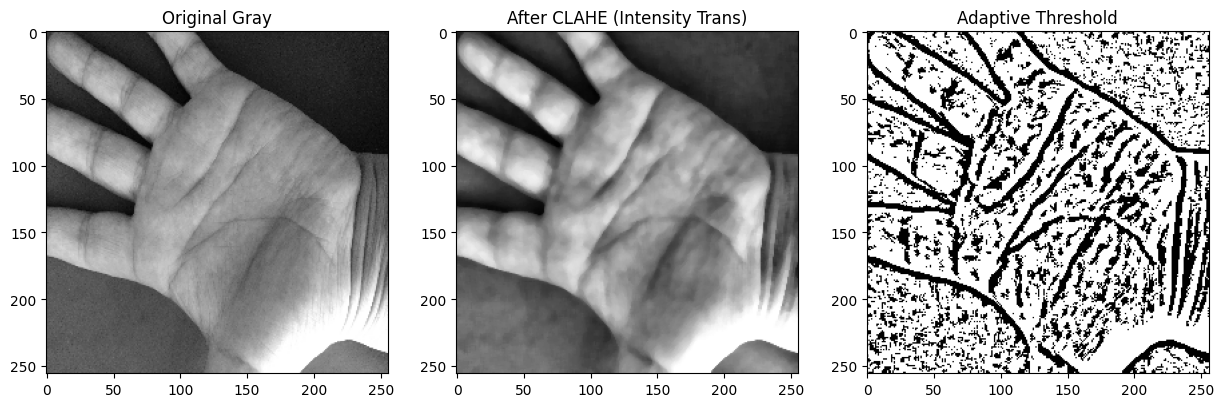

In [ ]:
def enhance_palmprint(image_path):
    # 1. LOAD & GRAYSCALE
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))

    # 2. PREPROCESSING (Median Filter sesuai deskripsimu)
    # Median blur sangat bagus untuk biometrik karena menjaga tepi (garis tangan)
    denoised = cv2.medianBlur(img, 5)

    # 3. INTENSITY TRANSFORMATION (CLAHE)
    # Ini jauh lebih bagus daripada HE biasa untuk gambar telapak tangan
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced_img = clahe.apply(denoised)

    # 4. ADAPTIVE THRESHOLDING (Dari kodemu sebelumnya)
    thresh = cv2.adaptiveThreshold(
        enhanced_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    return img, enhanced_img, thresh

# Eksekusi dan Visualisasi
if example_img_path:
    orig, enhanced, binary = enhance_palmprint(example_img_path)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.title('Original Gray'); plt.imshow(orig, cmap='gray')
    plt.subplot(1, 3, 2); plt.title('After CLAHE (Intensity Trans)'); plt.imshow(enhanced, cmap='gray')
    plt.subplot(1, 3, 3); plt.title('Adaptive Threshold'); plt.imshow(binary, cmap='gray')
    plt.show()